ZIP skip kar rahe hain. Direct data bana rahe hain
messy_sales_data.csv ban gaya

Before Cleaning: (8, 6)


/tmp/ipykernel_405/2786325940.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
/tmp/ipykernel_405/2786325940.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=


Ho gaya! Files ban gayin:
1. Cleaned_Data_2026-07-07.csv
2. Cleaned_Sales_Report_2026-07-07.csv
3. Sales_Report_Chart.png
Ab in 3 files ko Submit Work me upload kar do


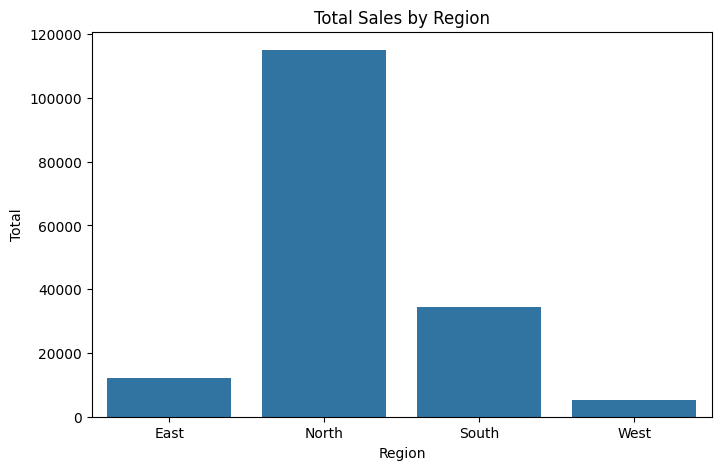

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

print("ZIP skip kar rahe hain. Direct data bana rahe hain")

# Step 1: Sample Messy Sales Data banate hain
data = {
    'OrderID': [101, 102, 102, 104, 105, 106, None, 108],
    'Date': ['2026-01-10', '2026-01-11', '2026-01-11', '2026-01-12', None, '2026-01-14', '2026-01-15', '2026-01-16'],
    'Product': ['Laptop', 'Mouse', 'mouse', 'Keyboard', 'Monitor', 'Laptop', 'Headphone', 'Mouse'],
    'Quantity': [2, 5, 5, None, 1, 3, 4, 2],
    'Price': [50000, 800, 800, 1200, 15000, None, 2000, 800],
    'Region': ['north', 'SOUTH', 'East', 'west', 'North', 'south', 'EAST', 'West']
}

df = pd.DataFrame(data)
df.to_csv('messy_sales_data.csv', index=False)
print("messy_sales_data.csv ban gaya")

# Step 2: Data Cleaning Automation
print("\nBefore Cleaning:", df.shape)
df = df.drop_duplicates()
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Price'].fillna(df['Price'].mean(), inplace=True)
df['Region'] = df['Region'].str.title()
df['Date'].fillna(pd.to_datetime('today').strftime('%Y-%m-%d'), inplace=True)

# Step 3: Reporting
df['Total'] = df['Quantity'] * df['Price']
report = df.groupby('Region')['Total'].sum().reset_index()

# Step 4: Save Files
today = datetime.now().strftime("%Y-%m-%d")
df.to_csv(f'Cleaned_Data_{today}.csv', index=False)
report.to_csv(f'Cleaned_Sales_Report_{today}.csv', index=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Total', data=report)
plt.title('Total Sales by Region')
plt.savefig('Sales_Report_Chart.png')

print(f"\nHo gaya! Files ban gayin:")
print(f"1. Cleaned_Data_{today}.csv")
print(f"2. Cleaned_Sales_Report_{today}.csv")
print(f"3. Sales_Report_Chart.png")
print("Ab in 3 files ko Submit Work me upload kar do")